In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("Customer-Churn-Records.csv")

In [4]:
df.drop("RowNumber",axis=1,inplace=True)

In [5]:
df.drop("Card Type",axis=1,inplace=True)

In [6]:
df.drop("Surname",axis=1,inplace=True)

In [7]:
df.drop("Geography",axis=1,inplace=True)

In [8]:
df.drop("Gender",axis=1,inplace=True)

In [9]:
df.drop("CustomerId",axis=1,inplace=True)

In [10]:
df['Exited'] = df['Exited'].map({0: 'No', 1: 'Yes'})

In [11]:
df


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
0,619,42,2,0.00,1,1,1,101348.88,Yes,1,2,464
1,608,41,1,83807.86,1,0,1,112542.58,No,1,3,456
2,502,42,8,159660.80,3,1,0,113931.57,Yes,1,3,377
3,699,39,1,0.00,2,0,0,93826.63,No,0,5,350
4,850,43,2,125510.82,1,1,1,79084.10,No,0,5,425
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,No,0,1,300
9996,516,35,10,57369.61,1,1,1,101699.77,No,0,5,771
9997,709,36,7,0.00,1,0,1,42085.58,Yes,1,3,564
9998,772,42,3,75075.31,2,1,0,92888.52,Yes,1,2,339


In [12]:
X=df.copy()


In [13]:
X.drop("Exited",axis=1,inplace=True)

In [14]:
y = df["Exited"]


In [15]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [16]:
df_t=scaler.fit_transform(X)

In [17]:
cov_mat=np.cov(df_t.T)

In [18]:
cov_mat

array([[ 1.00010001e+00, -3.96530206e-03,  8.42026021e-04,
         6.26900852e-03,  1.22391032e-02, -5.45902800e-03,
         2.56538887e-02, -1.38443131e-03, -2.70506792e-02,
        -1.26004988e-02,  7.66679211e-05],
       [-3.96530206e-03,  1.00010001e+00, -9.99782537e-03,
         2.83111994e-02, -3.06831563e-02, -1.17222012e-02,
         8.54806935e-02, -7.20176255e-03,  2.83558250e-01,
        -8.76461329e-04,  2.22263426e-03],
       [ 8.42026021e-04, -9.99782537e-03,  1.00010001e+00,
        -1.22551517e-02,  1.34451000e-02,  2.25851258e-02,
        -2.83649143e-02,  7.78460392e-03, -1.30485566e-02,
         8.66429003e-03, -1.01969432e-02],
       [ 6.26900852e-03,  2.83111994e-02, -1.22551517e-02,
         1.00010001e+00, -3.04210159e-01, -1.48598309e-02,
        -1.00851089e-02,  1.27987762e-02,  1.19136173e-01,
        -2.58833180e-03,  1.46093936e-02],
       [ 1.22391032e-02, -3.06831563e-02,  1.34451000e-02,
        -3.04210159e-01,  1.00010001e+00,  3.18346434e-03,
  

In [19]:
eigenvalues,eigenvectors=np.linalg.eig(cov_mat)

In [20]:
eigenvalues

array([1.42094863, 0.61604336, 0.70738004, 1.1894673 , 1.09397019,
       1.03280919, 0.96180901, 1.00936393, 1.00163101, 0.98324772,
       0.98442971])

In [21]:
eigenvectors

array([[-5.22320943e-02,  2.67930485e-02,  4.00332546e-02,
        -7.76109290e-02, -2.33842233e-01, -1.79235038e-01,
         3.63426623e-01,  6.10318138e-01, -1.54620957e-01,
         5.05903769e-01,  3.43084582e-01],
       [ 4.06879280e-01, -5.37927617e-01,  2.82519270e-01,
         5.15752716e-01, -3.93758455e-01,  9.10008127e-02,
        -4.49553575e-02,  9.80000704e-02, -3.66245162e-02,
        -1.46352286e-01,  3.94070341e-02],
       [-5.11454276e-02,  3.33601795e-02, -1.71953852e-02,
         2.90753622e-02,  3.19942617e-01,  3.00784132e-01,
        -5.01161759e-01,  4.48981078e-01,  1.42737671e-02,
        -2.77828258e-01,  5.21686127e-01],
       [ 5.35448902e-01, -3.43135475e-01, -6.21925357e-01,
        -4.46339537e-01,  1.01995856e-02,  8.49932508e-04,
        -1.96399209e-02,  8.49320726e-02,  3.64583955e-02,
        -2.81358501e-03, -2.23901478e-02],
       [-4.83226138e-01, -2.50250289e-01, -6.52614181e-01,
         5.15607381e-01,  1.20572048e-02, -8.27243776e-02,
  

In [22]:
from sklearn.decomposition import PCA

In [23]:
pca=PCA()

In [24]:
pca.fit(df_t)

PCA()

In [25]:
explained_variance=pca.explained_variance_ratio_

In [26]:
pca_2=PCA(n_components=1)
pca_2=pca_2.fit(df_t)
pca_2d=pca_2.transform(df_t)

In [27]:
pca_2d

array([[0.84631648],
       [1.64334103],
       [0.77368608],
       ...,
       [0.572265  ],
       [0.81116899],
       [0.2999677 ]], shape=(10000, 1))

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test1 = train_test_split(
    pca_2d, y, test_size=0.2, random_state=42
)


In [29]:
cov_matr=np.cov(pca_2d.T)
cov_matr

array(1.42094863)

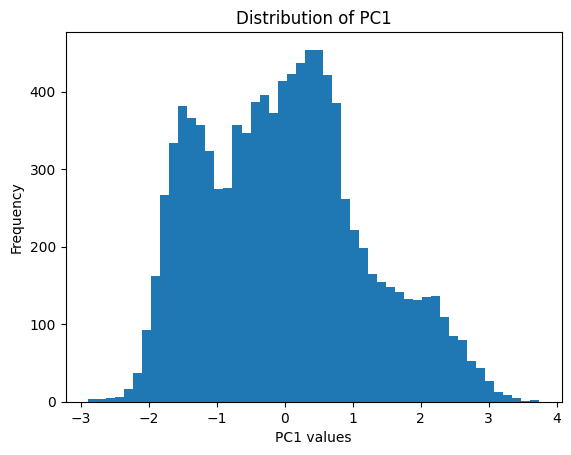

In [30]:
import matplotlib.pyplot as plt

plt.hist(pca_2d, bins=50)
plt.title("Distribution of PC1")
plt.xlabel("PC1 values")
plt.ylabel("Frequency")
plt.show()


In [31]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(X_train, y_train)


LogisticRegression()

In [32]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred1 = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test1, y_pred1))
print("\nConfusion Matrix:\n", confusion_matrix(y_test1, y_pred1))
print("\nClassification Report:\n", classification_report(y_test1, y_pred1))


Accuracy: 0.916

Confusion Matrix:
 [[1564   43]
 [ 125  268]]

Classification Report:
               precision    recall  f1-score   support

          No       0.93      0.97      0.95      1607
         Yes       0.86      0.68      0.76       393

    accuracy                           0.92      2000
   macro avg       0.89      0.83      0.86      2000
weighted avg       0.91      0.92      0.91      2000



In [33]:

lda = LinearDiscriminantAnalysis(n_components=1)


In [34]:
X_lda = lda.fit_transform(df_t, y)


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test1 = train_test_split(
    X_lda, y, test_size=0.2, random_state=42
)


In [36]:
print("Explained variance ratio:", lda.explained_variance_ratio_)


Explained variance ratio: [1.]


In [37]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(X_train, y_train)


LogisticRegression()

In [38]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred1 = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test1, y_pred1))
print("\nConfusion Matrix:\n", confusion_matrix(y_test1, y_pred1))
print("\nClassification Report:\n", classification_report(y_test1, y_pred1))


Accuracy: 0.999

Confusion Matrix:
 [[1606    1]
 [   1  392]]

Classification Report:
               precision    recall  f1-score   support

          No       1.00      1.00      1.00      1607
         Yes       1.00      1.00      1.00       393

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

